In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv("CarPrice_Assignment.csv")
print(data.head())
print(data.info())

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [3]:
data = data.drop(['CarName', 'car_ID'],axis=1)
data=pd.get_dummies(data, drop_first=True)
x=data.drop('price',axis=1)
y=data['price']

In [4]:
scaler=StandardScaler()
x=scaler.fit_transform(x)
y=scaler.fit_transform(np.array(y).reshape(-1,1))
x_train, x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [11]:
sgd_model = SGDRegressor(max_iter=1000,tol=1e-3)
sgd_model.fit(x_train, y_train)
y_pred = sgd_model.predict(x_test)
x_pred = sgd_model.predict(x_test)

C:\ProgramData\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [13]:
mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)

In [14]:
print('Name: Sanjeev Kumar')
print('Reg. No: 25012334')
print("Mean Squared Score:",r2)

Name: Sanjeev Kumar
Reg. No: 25012334
Mean Squared Score: 0.8277477515027339


In [15]:
print("\nModel Coefficients:")
print("Coefficient:",sgd_model.coef_)
print("Intercept:", sgd_model.intercept_)


Model Coefficients:
Coefficient: [ 0.03091598  0.10654357  0.01117081  0.17396181  0.0182441   0.16966191
  0.28268609 -0.02039623 -0.07946773  0.00363556  0.10493005  0.03583599
 -0.03693091 -0.0517481  -0.01978316  0.01930807  0.02153582 -0.01861963
 -0.09115234 -0.01559151 -0.09591093 -0.03225382  0.06104315  0.2118271
  0.01496981 -0.10202076  0.07350324 -0.0162379   0.00272628  0.00980282
 -0.03037781 -0.14349704 -0.07514921  0.00089281 -0.02823865  0.00980282
 -0.00162866 -0.01353858  0.01978316 -0.01783296 -0.03334321 -0.04023382
 -0.01671344]
Intercept: [-0.01275471]


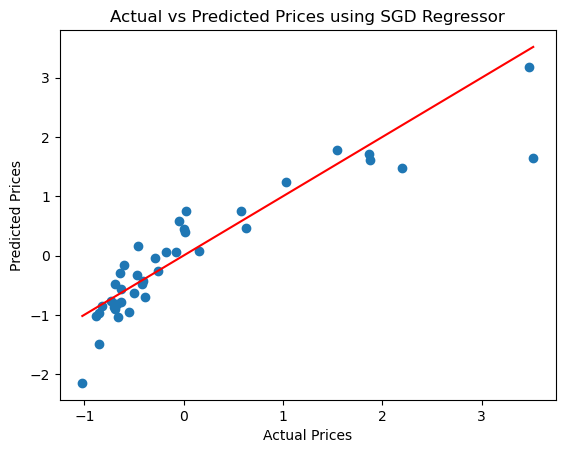

In [16]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices using SGD Regressor")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],color='red')
plt.show()